In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import importlib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models

####################################################################################################

from sklearn.metrics import f1_score
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
from tqdm import tqdm
from collections import OrderedDict

####################################################################################################

from utils import *
from data_fetch import download_dataset


# Globals

In [2]:
# PATHS AND SEED --!-- DO NOT EDIT --!--
ROOT_DIR = Path('./data/')
ORGANIZED_DIR = ROOT_DIR / 'organized_data'
DATA_DIR = ROOT_DIR / 'data'
TEST_DIR = ORGANIZED_DIR / 'test/'
TRAIN_DIR = ORGANIZED_DIR / 'train/'
VAL_DIR = ORGANIZED_DIR / 'val/'
MODEL_SAVE_PATH_BASELINE = Path('model/baseline')
MODEL_SAVE_PATH_RESNET = Path('model/resnet')

# Create necessary directories
MODEL_SAVE_PATH_BASELINE.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH_RESNET.mkdir(parents=True, exist_ok=True)
  
# HYPERPARAMETERS
SEED = 42
BATCH_SIZE = 64
IMG_SIZE = (224,224)
LEARNING_RATE = 0.00001
NUM_EPOCHS_BASELINE = 60
NUM_EPOCHS_RESNET = 8

In [3]:
set_seed(SEED)

Graine aléatoire fixée à 42 🌱


# Data Fetching & Initial Cleaning

In [4]:
download_dataset('harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset', ROOT_DIR)

✅ Dataset already exists at data. Skipping download.


**Deleting the Samples folder as we will not use it**

In [5]:
!rm -rf {DATA_DIR / 'Samples'}
print("Removed 'Samples' directory from the dataset")

Removed 'Samples' directory from the dataset


In [6]:
plot_class_distribution(DATA_DIR)

In [7]:
show_class_distribution(DATA_DIR)

Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 3714
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1905


In [8]:
fix_images(DATA_DIR)

Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/422_10000_6200_img_8UXGVkszCbidTR49_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2857_9000_11200_img_NgkRiqvlSMUKRxSO_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_CFAY073B8sznfZJG_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2_400_0_img_0t9JBHeOeBHgaLmJ_JAV_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2690_2600_9400_img_8jmWSIh9LhIh4p4e_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/15_600_600_img_yypoVwlHZPchMcLa_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/1064_9200_7400_img_xCVKEyUQBMP2ef8r_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/460_5400_3000_img_lHgjbs0x2eQq1CKp_GBR_cls_0.jpg of type: jpeg
Accepted file: data/

In [9]:
show_class_distribution(DATA_DIR)

Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 3714
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1905


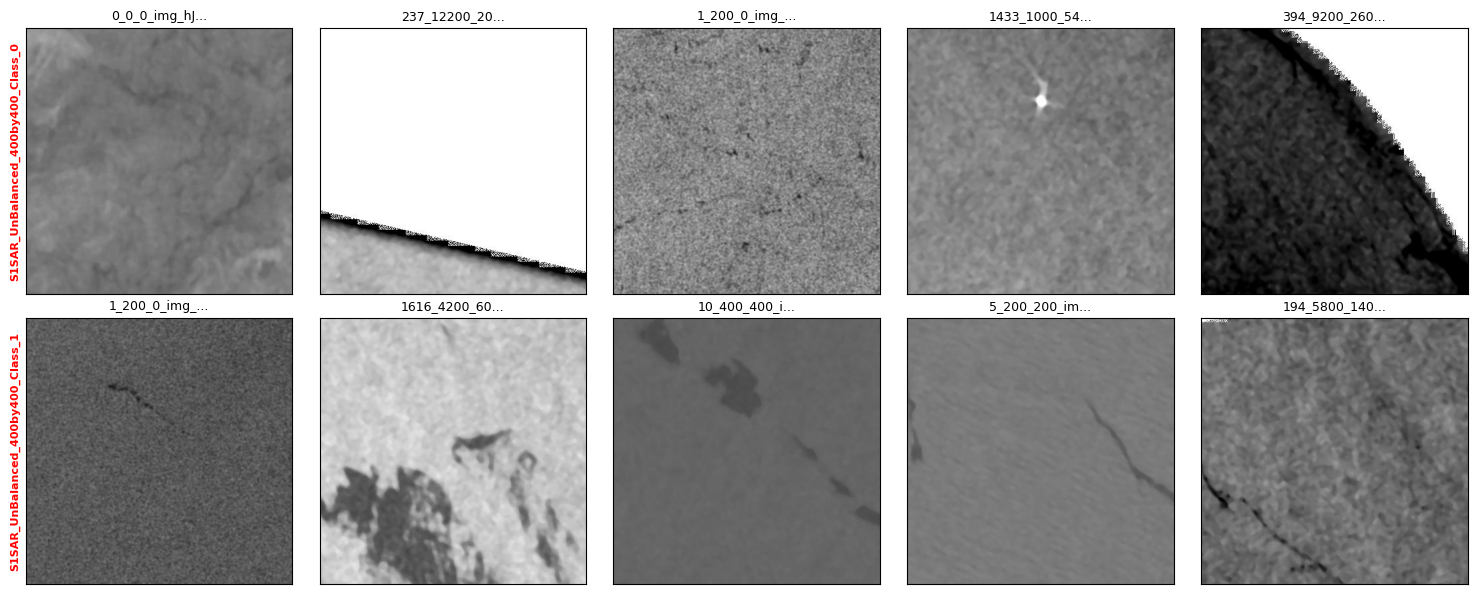

In [10]:
display_random_samples(DATA_DIR)

In [11]:
show_img_size_and_channels("data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_0CugGbeejr96zxqr_SFr_cls_0.jpg")

Image: data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_0CugGbeejr96zxqr_SFr_cls_0.jpg - Size: (400, 400) (Width x Height) - Channels: 3


In [12]:
find_and_remove_black_images(DATA_DIR, threshold=1 , delete=True)

🧹 Nombre d'images noires détectées : 0
🗑️ Toutes les images noires ont été supprimées !


[]

In [13]:
# Supprimer les images blanches

In [14]:
count_images_by_region(DATA_DIR)

Nombre d'images par région:
GBR: 2850 images.
JAV: 631 images.
ADR: 72 images.
LUC: 58 images.
BOR: 43 images.
MLA: 38 images.
SIN: 1079 images.
BAH: 74 images.
SFr: 80 images.
JAP: 34 images.
GIB: 165 images.
EGY: 97 images.
NOR: 48 images.
VEN: 33 images.
CHS: 24 images.
TRI: 6 images.
BLS: 4 images.
PHI: 132 images.
ISR: 40 images.
GGu: 71 images.
COR: 11 images.
BOS: 3 images.
MAU: 10 images.
SUE: 1 images.
NWS: 4 images.
THA: 11 images.


In [15]:
create_spatial_split_full(
    data_dir=DATA_DIR, 
    output_dir=ORGANIZED_DIR,
    train_ratio=0.8, 
    val_ratio=0.1, 
    test_ratio=0.1
)

🔍 Analyse du dossier source : data/data

📊 Répartition finale : 4560 Train | 841 Val | 218 Test
🚀 Copie en cours...
✅ Terminé ! 5619 images traitées.


In [16]:
check_duplicates(TRAIN_DIR)

⚠️ 59 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
   1. data/organized_data/train/0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg
   2. data/organized_data/train/0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
 - Fichier : 535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg
   1. data/organized_data/train/0/535_1800_2600_img_YTAQHQ6Ub5AO2wEx_SIN_cls_0.jpg
   2. data/organized_data/train/0/535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg
 - Fichier : 2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
   1. data/organized_data/train/0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg
   2. data/organized_data/train/0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
 - Fichier : 1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg
   1. data/organized_data/train/0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN_cls_0.jpg
   2. data/organized_data/train/0/1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg
 - Fichier 

[('2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg',
  'data/organized_data/train/0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg',
  'data/organized_data/train/0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg'),
 ('535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg',
  'data/organized_data/train/0/535_1800_2600_img_YTAQHQ6Ub5AO2wEx_SIN_cls_0.jpg',
  'data/organized_data/train/0/535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg'),
 ('2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg',
  'data/organized_data/train/0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg',
  'data/organized_data/train/0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg'),
 ('1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg',
  'data/organized_data/train/0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN_cls_0.jpg',
  'data/organized_data/train/0/1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg'),
 ('455_8800_6400_img_yNyIaqiovKFSBdq1_GBR_cls_0.jpg',
  'data/organized_data/train/0/455_8800_6400_img_joguExzqFzhN

In [17]:
check_duplicates(TEST_DIR)

✅ Aucun doublon de contenu trouvé dans ou entre les dossiers.


[]

In [18]:
check_duplicates(VAL_DIR)

⚠️ 16 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
   1. data/organized_data/val/1/0_0_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
   2. data/organized_data/val/1/0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
 - Fichier : 1_200_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
   1. data/organized_data/val/1/1_200_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
   2. data/organized_data/val/1/1_200_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
 - Fichier : 1_200_0_img_BnQrY5XBUEExFNYk_GGu_cls_1.jpg
   1. data/organized_data/val/1/1_200_0_img_VXIfDkl7u9kt5FOL_GGu_cls_1.jpg
   2. data/organized_data/val/1/1_200_0_img_BnQrY5XBUEExFNYk_GGu_cls_1.jpg
 - Fichier : 4_0_200_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
   1. data/organized_data/val/1/4_0_200_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
   2. data/organized_data/val/1/4_0_200_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
 - Fichier : 0_0_0_img_9xIY4sY47LZXQ7XH_GGu_cls_1.jpg
   1. data/organized_data/val/1/0_0_0_img_R2VWYHSQIBccFcI9_G

[('0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg',
  'data/organized_data/val/1/0_0_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg',
  'data/organized_data/val/1/0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg'),
 ('1_200_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg',
  'data/organized_data/val/1/1_200_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg',
  'data/organized_data/val/1/1_200_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg'),
 ('1_200_0_img_BnQrY5XBUEExFNYk_GGu_cls_1.jpg',
  'data/organized_data/val/1/1_200_0_img_VXIfDkl7u9kt5FOL_GGu_cls_1.jpg',
  'data/organized_data/val/1/1_200_0_img_BnQrY5XBUEExFNYk_GGu_cls_1.jpg'),
 ('4_0_200_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg',
  'data/organized_data/val/1/4_0_200_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg',
  'data/organized_data/val/1/4_0_200_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg'),
 ('0_0_0_img_9xIY4sY47LZXQ7XH_GGu_cls_1.jpg',
  'data/organized_data/val/1/0_0_0_img_R2VWYHSQIBccFcI9_GGu_cls_1.jpg',
  'data/organized_data/val/1/0_0_0_img_9xIY4sY47LZXQ7XH_GGu_cls_1.jpg'),
 ('5_200_200_img_oAo0xyFOE8

In [19]:
remove_duplicates(TRAIN_DIR,TEST_DIR,VAL_DIR)

Recherche des doublons à supprimer...
⚠️ 91 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
   1. data/organized_data/train/0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg
   2. data/organized_data/train/0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
 - Fichier : 535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg
   1. data/organized_data/train/0/535_1800_2600_img_YTAQHQ6Ub5AO2wEx_SIN_cls_0.jpg
   2. data/organized_data/train/0/535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg
 - Fichier : 2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
   1. data/organized_data/train/0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg
   2. data/organized_data/train/0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
 - Fichier : 1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg
   1. data/organized_data/train/0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN_cls_0.jpg
   2. data/organized_data/train/0/1995_600_7000_img_87nd

91

In [20]:
clean_low_variance_dataset(TRAIN_DIR, threshold=2.0)

Cleaning train: 0it [00:00, ?it/s]
Cleaning 1: 100%|██████████| 1469/1469 [00:00<00:00, 2255.39it/s]

✅ Nettoyage terminé : 32 images inutiles supprimées.


In [21]:
print("="*50)
print("DISTRIBUTION FOR TRAIN DIR:")
show_class_distribution(TRAIN_DIR)
print("="*50)


print("="*50)
print("DISTRIBUTION FOR TEST DIR:")
show_class_distribution(TEST_DIR)
print("="*50)

print("="*50)
print("DISTRIBUTION FOR VAL DIR:")
show_class_distribution(VAL_DIR)
print("="*50)


DISTRIBUTION FOR TRAIN DIR:
Class: 0 - Number of samples: 3002
Class: 1 - Number of samples: 1467
DISTRIBUTION FOR TEST DIR:
Class: 0 - Number of samples: 126
Class: 1 - Number of samples: 92
DISTRIBUTION FOR VAL DIR:
Class: 0 - Number of samples: 527
Class: 1 - Number of samples: 282


# Simple CNN

✅ Stats (Preprocessed) - Mean: 0.6781, Std: 0.1646
Sampler équilibré - Classe 0: 3002 | Classe 1: 1467
⚖️ Class weights désactivés (weights=None) pour ce test.


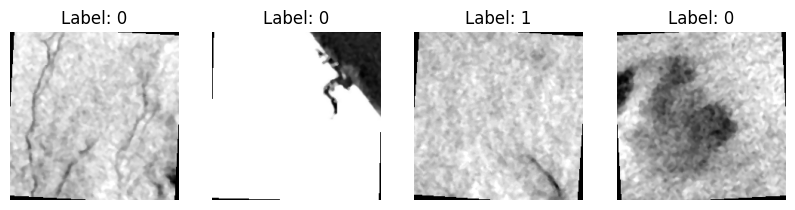

In [22]:
# --- 2. Calcul des stats sur images PRÉ-TRAITÉES (Clipping + Débruitage) ---
# On utilise preprocess_sar pour que la normalisation soit calée sur les nouvelles intensités
temp_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: np.array(x)),
    transforms.Lambda(lambda x: preprocess_sar(x)), # Clipping p99 + MedianBlur
    transforms.ToTensor() 
])

temp_dataset = datasets.ImageFolder(TRAIN_DIR, transform=temp_transforms)
temp_loader = DataLoader(temp_dataset, batch_size=BATCH_SIZE, num_workers=2)

mean, std = get_mean_and_std(temp_loader)
MEAN = [mean.item()]
STD = [std.item()]
print(f"✅ Stats (Preprocessed) - Mean: {MEAN[0]:.4f}, Std: {STD[0]:.4f}")

# --- 3. Définition des vrais Transforms ---

# Pipeline commun incluant les découvertes de l'EDA
common_preprocess = [
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: np.array(x)),
    transforms.Lambda(lambda x: preprocess_sar(x)),
    transforms.ToPILImage() # Retour en PIL pour les augmentations géométriques
]

train_transforms = transforms.Compose([
    *common_preprocess,
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomVerticalFlip(p=0.3), 
    transforms.RandomRotation(5), 
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

test_val_transforms = transforms.Compose([
    *common_preprocess, # On applique le même clipping/débruitage partout
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# --- 4. Datasets et Loaders ---
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=test_val_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_val_transforms)

train_sampler, class_counts = create_balanced_sampler(train_dataset)
print(f"Sampler équilibré - Classe 0: {class_counts[0]} | Classe 1: {class_counts[1]}")

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=train_sampler, 
    num_workers=2, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

# --- 5. Entraînement avec sampler équilibré (sans class weights) ---
weights = None
print("⚖️ Class weights désactivés (weights=None) pour ce test.")

# --- 6. Vérification finale ---
# On passe STD et MEAN pour que la fonction puisse dé-normaliser l'image correctement
verify_batch(train_loader, STD, MEAN)

In [23]:
weights

In [24]:
class SimpleCNN(nn.Module):
    def __init__(self, img_size=IMG_SIZE):
        super(SimpleCNN, self).__init__()
        
        self.conv_section = nn.Sequential(OrderedDict([
            # Block 1
            ('conv1', nn.Conv2d(1, 32, kernel_size=3, padding=1)),
            ('bn1', nn.BatchNorm2d(32)),
            ('relu1', nn.ReLU()),
            ('pool1', nn.MaxPool2d(2, 2)),  # 224 -> 112
            
            # Block 2
            ('conv2', nn.Conv2d(32, 64, kernel_size=3, padding=1)),
            ('bn2', nn.BatchNorm2d(64)),
            ('relu2', nn.ReLU()),
            ('pool2', nn.MaxPool2d(2, 2)),  # 112 -> 56

            # Block 3
            ('conv3', nn.Conv2d(64, 128, kernel_size=3, padding=1)),
            ('bn3', nn.BatchNorm2d(128)),
            ('relu3', nn.ReLU()),
            ('pool3', nn.MaxPool2d(2, 2)),  # 56 -> 28

            # Block 4
            ('conv4', nn.Conv2d(128, 256, kernel_size=3, padding=1)),
            ('bn4', nn.BatchNorm2d(256)),
            ('relu4', nn.ReLU()),
            ('pool4', nn.MaxPool2d(2, 2))   # 28 -> 14
        ]))

        self.flatten_size = 256 * (img_size[0] // 16) * (img_size[1] // 16)

        self.classifier = nn.Sequential(OrderedDict([
            ('flatten', nn.Flatten()),
            ('fc1', nn.Linear(self.flatten_size, 256)),
            ('relu_fc', nn.ReLU()),
            ('dropout', nn.Dropout(0.5)),
            ('fc2', nn.Linear(256, 2))
        ]))

    def forward(self, x):
        x = self.conv_section(x)
        x = self.classifier(x)
        return x

In [25]:
def train_model(model, train_loader, val_loader, epochs=40, lr=1e-4, weights=None, device=None, model_save_path=f"{ROOT_DIR}/model"):
    model.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=weights.to(device) if weights is not None else None)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    class HistoryWrapper:
        def __init__(self):
            self.history = {
                'accuracy': [],
                'val_accuracy': [],
                'val_f1': [],
                'loss': [],
                'val_loss': []
            }

    results = HistoryWrapper()

    patience_limit = 7
    min_delta = 0.002
    trigger_times = 0
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        total_train_loss = 0
        train_correct = 0
        train_total = 0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
            train_bar.set_postfix(loss=loss.item())

        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        val_correct = 0
        val_total = 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                total_val_loss += criterion(outputs, labels).item()
                
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        train_acc = train_correct / train_total if train_total > 0 else 0.0
        val_acc = val_correct / val_total if val_total > 0 else 0.0
        val_f1 = f1_score(all_labels, all_preds, average='weighted')

        results.history['loss'].append(avg_train_loss)
        results.history['val_loss'].append(avg_val_loss)
        results.history['accuracy'].append(train_acc)
        results.history['val_accuracy'].append(val_acc)
        results.history['val_f1'].append(val_f1)

        print(
            f"✅ Fin Epoch {epoch+1} - "
            f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f} | Val Loss: {avg_val_loss:.4f}"
        )

        if avg_val_loss < (best_val_loss - min_delta):
            best_val_loss = avg_val_loss
            trigger_times = 0
            torch.save(model.state_dict(), f'{model_save_path}/best_model.pth')
            print("🌟 Nouveau record ! Modèle sauvegardé.")
        else:
            trigger_times += 1
            print(f"⚠ Pas d'amélioration significative ({trigger_times}/{patience_limit})")

        scheduler.step(avg_val_loss)
            
        if trigger_times >= patience_limit:
            print(f"🛑 Early Stopping déclenché à l'époque {epoch+1} !")
            break 
            
    return results

**TRAINING**

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Protocole simple CNN: 1 LR + 1 métrique cible
CNN_LEARNING_RATE = 3e-5
TARGET_METRIC = 'val_f1'

baseline = SimpleCNN(img_size=IMG_SIZE)
history = train_model(
    baseline,
    train_loader,
    val_loader,
    NUM_EPOCHS_BASELINE,
    CNN_LEARNING_RATE,
    weights=None,
    device=device,
    model_save_path=MODEL_SAVE_PATH_BASELINE
)

print(f"✅ CNN trained with lr={CNN_LEARNING_RATE} | target metric={TARGET_METRIC}")

Epoch 1/60 [Train]: 100%|██████████| 70/70 [00:03<00:00, 18.55it/s, loss=0.539]


✅ Fin Epoch 1 - Train Acc: 0.8342 | Val Acc: 0.8368 | Val F1: 0.8397 | Val Loss: 0.3434
🌟 Nouveau record ! Modèle sauvegardé.


Epoch 2/60 [Train]: 100%|██████████| 70/70 [00:03<00:00, 19.95it/s, loss=0.42] 


✅ Fin Epoch 2 - Train Acc: 0.8353 | Val Acc: 0.8331 | Val F1: 0.8359 | Val Loss: 0.3491
⚠ Pas d'amélioration significative (1/7)


Epoch 3/60 [Train]: 100%|██████████| 70/70 [00:03<00:00, 19.91it/s, loss=0.322]


...

✅ Fin Epoch 22 - Train Acc: 0.9161 | Val Acc: 0.9061 | Val F1: 0.9068 | Val Loss: 0.2512
⚠ Pas d'amélioration significative (5/7)


Epoch 23/60 [Train]: 100%|██████████| 70/70 [00:03<00:00, 19.79it/s, loss=0.334]


✅ Fin Epoch 23 - Train Acc: 0.9036 | Val Acc: 0.9073 | Val F1: 0.9075 | Val Loss: 0.2346
⚠ Pas d'amélioration significative (6/7)


Epoch 24/60 [Train]: 100%|██████████| 70/70 [00:03<00:00, 19.67it/s, loss=0.186] 


✅ Fin Epoch 24 - Train Acc: 0.9103 | Val Acc: 0.9221 | Val F1: 0.9222 | Val Loss: 0.2140
⚠ Pas d'amélioration significative (7/7)
🛑 Early Stopping déclenché à l'époque 24 !
✅ CNN trained with lr=3e-05 | target metric=val_f1


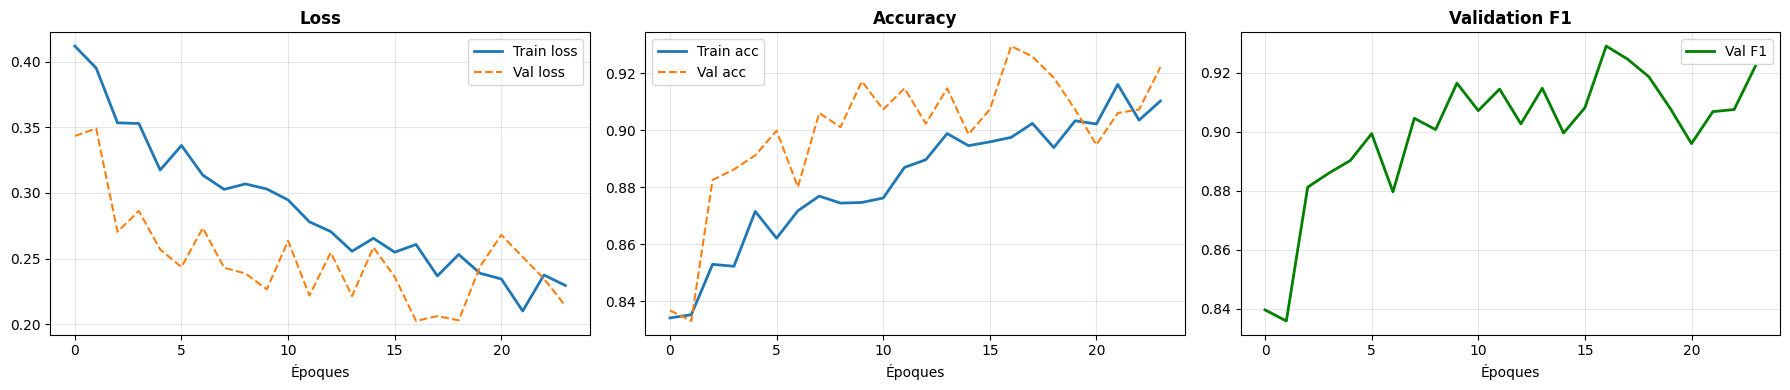

In [27]:
plot_history(history.history)

In [28]:
print(f"Target metric ({TARGET_METRIC}) best value: {max(history.history['val_f1']):.4f}")
print(f"Final val_acc (SimpleCNN): {history.history['val_accuracy'][-1]:.4f}")
print(f"Final val_loss (SimpleCNN): {history.history['val_loss'][-1]:.4f}")

Target metric (val_f1) best value: 0.9289
Final val_acc (SimpleCNN): 0.9221
Final val_loss (SimpleCNN): 0.2140



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Class 0       0.96      0.99      0.98       126
     Class 1       0.99      0.95      0.97        92

    accuracy                           0.97       218
   macro avg       0.98      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218



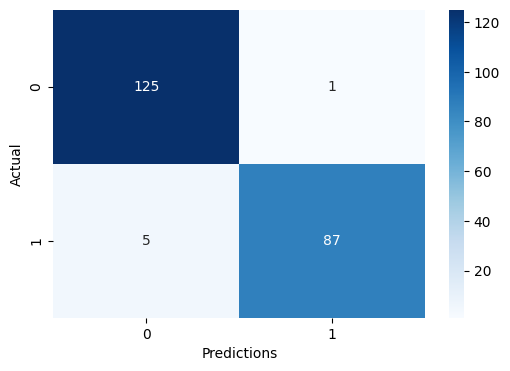

In [29]:
evaluate_test_set(baseline, test_loader, device)

# RESNET18 TEST

In [30]:
resnet = models.resnet18(weights='DEFAULT')

# 1. Adapté pour le Grayscale (1 canal)
resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# 2. Remplacer la couche FC par un bloc avec Dropout
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(p=0.5),           # Force le modèle à généraliser
    nn.Linear(num_ftrs, 2)       # Sortie binaire
)

resnet.to(device)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [31]:
history_resnet = train_model(resnet, train_loader, val_loader, NUM_EPOCHS_RESNET, LEARNING_RATE, weights=None, device=device, model_save_path=MODEL_SAVE_PATH_RESNET)

Epoch 1/8 [Train]: 100%|██████████| 70/70 [00:03<00:00, 20.92it/s, loss=0.318]


✅ Fin Epoch 1 - Train Acc: 0.7953 | Val Acc: 0.8603 | Val F1: 0.8612 | Val Loss: 0.3040
🌟 Nouveau record ! Modèle sauvegardé.


Epoch 2/8 [Train]: 100%|██████████| 70/70 [00:03<00:00, 20.97it/s, loss=0.361]


✅ Fin Epoch 2 - Train Acc: 0.8689 | Val Acc: 0.8826 | Val F1: 0.8814 | Val Loss: 0.2742
🌟 Nouveau record ! Modèle sauvegardé.


Epoch 3/8 [Train]: 100%|██████████| 70/70 [00:03<00:00, 21.22it/s, loss=0.236]


...

✅ Fin Epoch 6 - Train Acc: 0.9306 | Val Acc: 0.9357 | Val F1: 0.9358 | Val Loss: 0.1589
🌟 Nouveau record ! Modèle sauvegardé.


Epoch 7/8 [Train]: 100%|██████████| 70/70 [00:03<00:00, 21.06it/s, loss=0.175] 


✅ Fin Epoch 7 - Train Acc: 0.9322 | Val Acc: 0.9357 | Val F1: 0.9358 | Val Loss: 0.1543
🌟 Nouveau record ! Modèle sauvegardé.


Epoch 8/8 [Train]: 100%|██████████| 70/70 [00:03<00:00, 21.13it/s, loss=0.0684]


✅ Fin Epoch 8 - Train Acc: 0.9313 | Val Acc: 0.9407 | Val F1: 0.9409 | Val Loss: 0.1545
⚠ Pas d'amélioration significative (1/7)


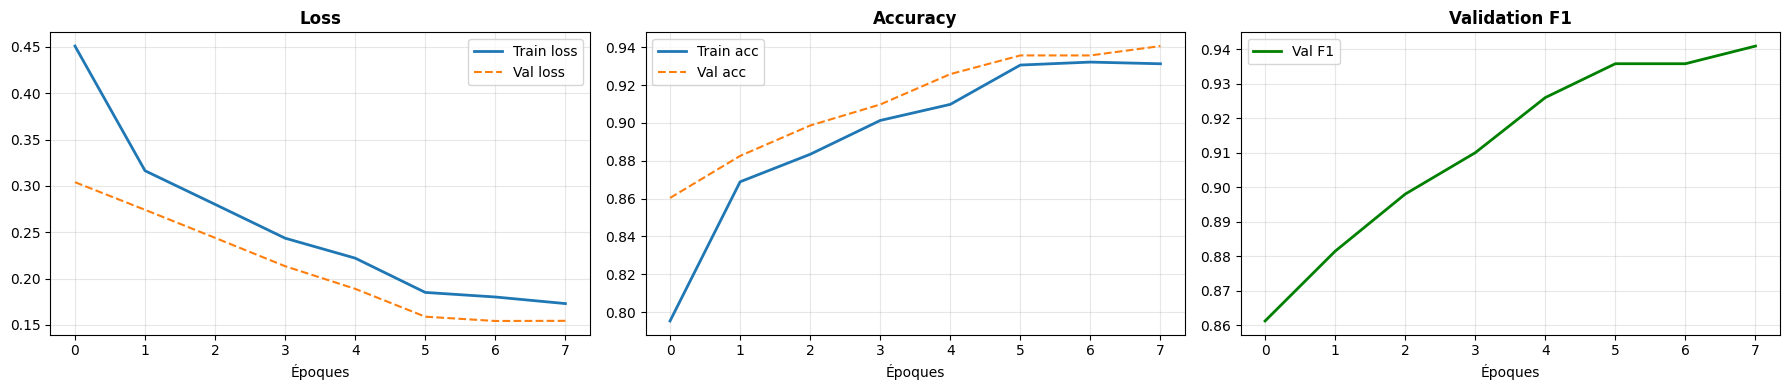

In [32]:
plot_history(history_resnet.history)


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Class 0       0.98      0.97      0.98       126
     Class 1       0.96      0.98      0.97        92

    accuracy                           0.97       218
   macro avg       0.97      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218



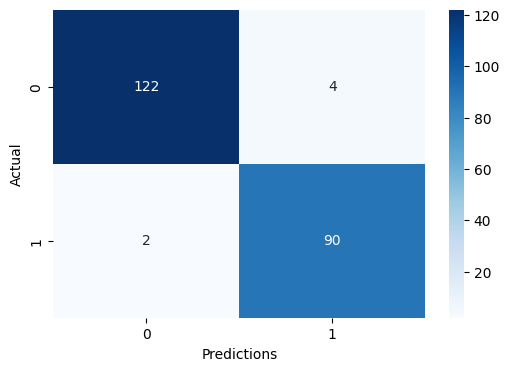

In [33]:
evaluate_test_set(resnet, test_loader, device)

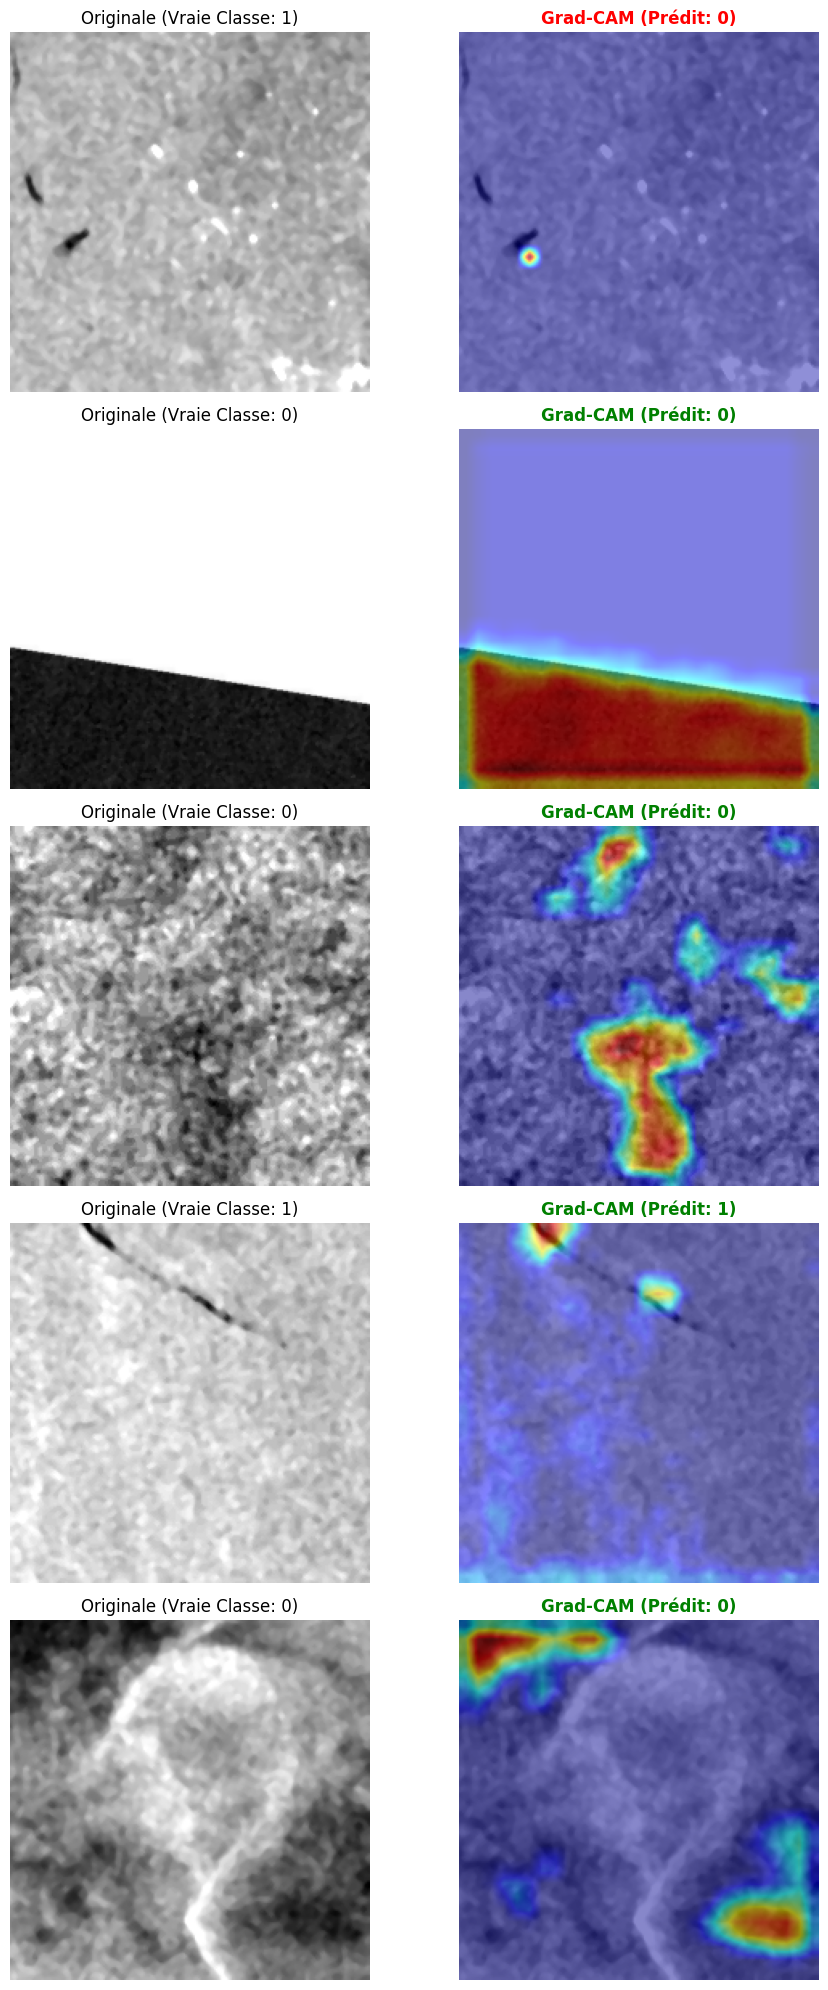

In [34]:
# Affiche 5 images au hasard pour le SimpleCNN
visualize_random_gradcam(
    model=baseline, 
    target_layer=baseline.conv_section.conv4, # Dernière couche convolutive de SimpleCNN
    dataset=test_dataset, 
    device=device, 
    num_images=5
)

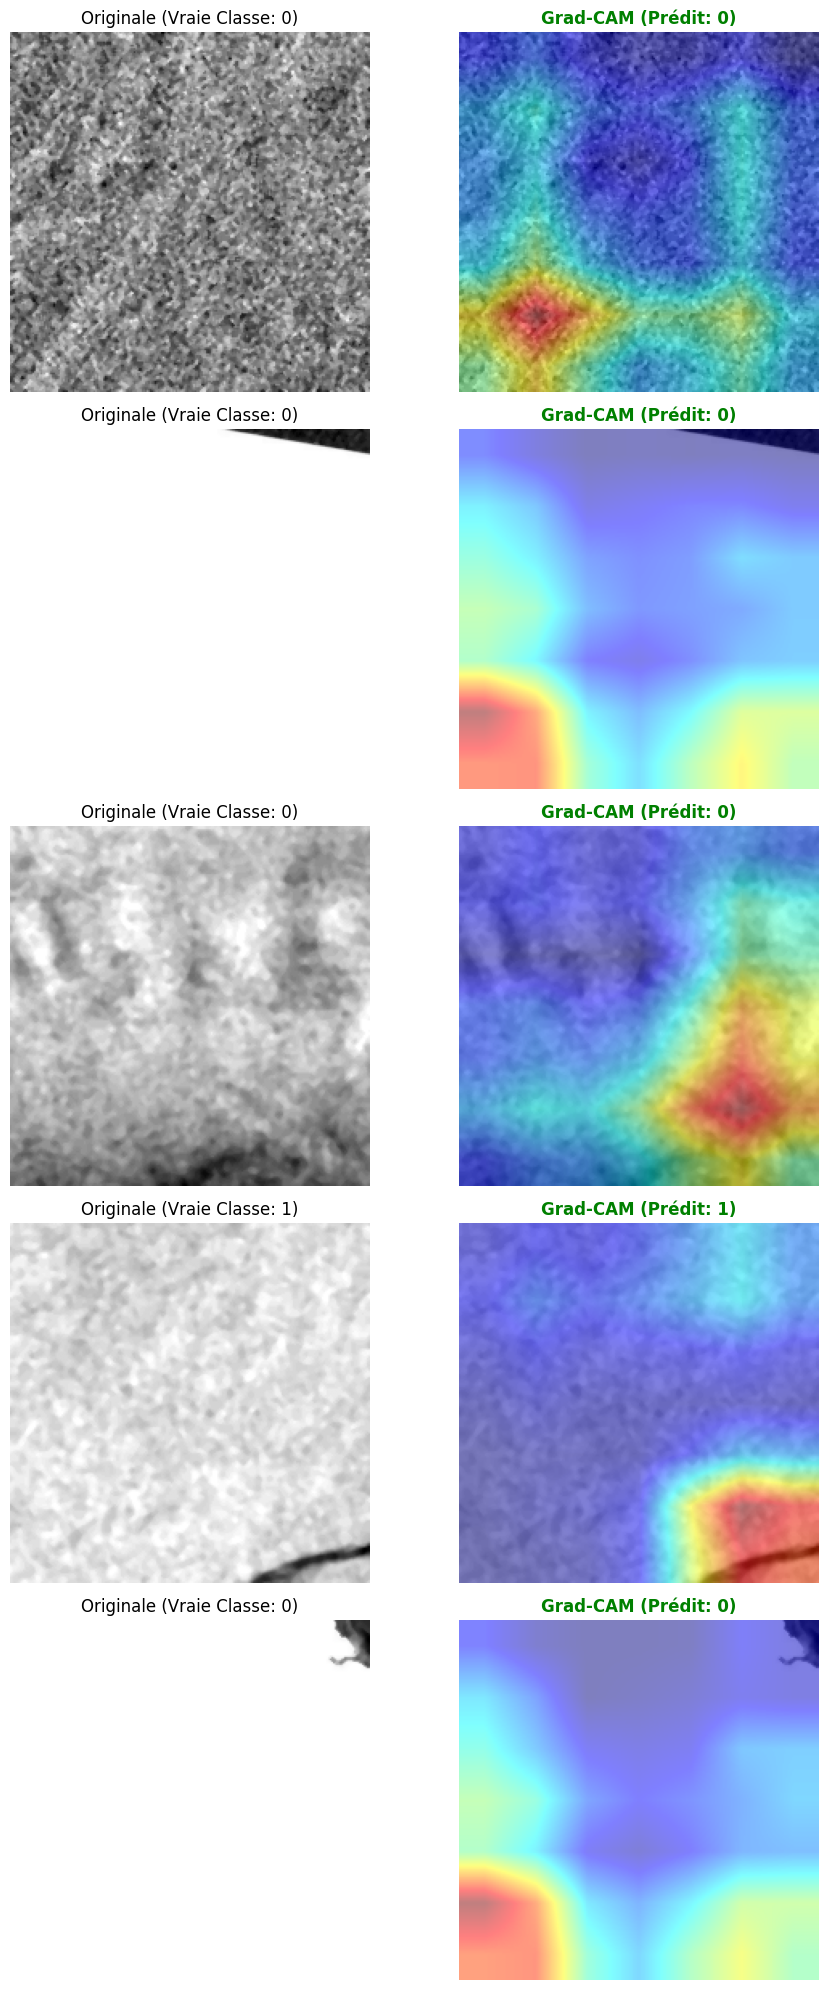

In [35]:
# Affiche 5 images au hasard pour le ResNet
visualize_random_gradcam(
    model=resnet, 
    target_layer=resnet.layer4[-1], # La dernière couche convolutive de ResNet
    dataset=test_dataset,
    device=device, 
    num_images=5
)